In [ ]:
print("Spam Classifier Project")
print("Google Colab is ready!")

Spam Classifier Project
Google Colab is ready!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import urllib.request

url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv"

urllib.request.urlretrieve(url, "spam.csv")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [ ]:
import pandas as pd

df = pd.read_csv(
    "spam.csv",
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nSpam and Ham messages:")
print(df["label"].value_counts())

Dataset shape: (5572, 2)

Column names:
Index(['label', 'message'], dtype='object')

Spam and Ham messages:
label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
label      0
message    0
dtype: int64

Duplicate rows:
403


In [ ]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:")
print(df.shape)

print("\nDuplicate rows remaining:")
print(df.duplicated().sum())

Dataset shape after removing duplicates:
(5169, 2)

Duplicate rows remaining:
0


In [ ]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

print(df["label_num"].value_counts())

label_num
0    4516
1     653
Name: count, dtype: int64


In [ ]:
X = df["message"]
y = df["label_num"]

print("Input data:")
print(X.head())

print("\nTarget data:")
print(y.head())

Input data:
0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: message, dtype: object

Target data:
0    0
1    0
2    1
3    0
4    0
Name: label_num, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [ ]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

Training feature shape: (4135, 7414)
Testing feature shape: (1034, 7414)


In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [ ]:
y_pred_lr = logistic_model.predict(X_test_tfidf)

y_prob_lr = logistic_model.predict_proba(X_test_tfidf)[:, 1]

print("Predictions completed!")

Predictions completed!


In [ ]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_roc_auc, 4))

Logistic Regression Results
----------------------------
Accuracy : 0.9565
Precision: 0.9778
Recall   : 0.6718
F1 Score : 0.7964
ROC-AUC  : 0.9917


In [ ]:
lr_cv_scores = cross_val_score(
    logistic_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression 5-Fold CV Scores:")
print(lr_cv_scores)

print("\nMean CV Accuracy:", round(lr_cv_scores.mean(), 4))

Logistic Regression 5-Fold CV Scores:
[0.93591294 0.93349456 0.93712213 0.9407497  0.94800484]

Mean CV Accuracy: 0.9391


In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train_tfidf, y_train)

print("Random Forest trained successfully!")


y_pred_rf = random_forest_model.predict(X_test_tfidf)

y_prob_rf = random_forest_model.predict_proba(X_test_tfidf)[:, 1]

print("Random Forest predictions completed!")

Random Forest trained successfully!
Random Forest predictions completed!


In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Results
---------------------
Accuracy : 0.9787
Precision: 0.991
Recall   : 0.8397
F1 Score : 0.9091
ROC-AUC  : 0.991


In [ ]:
rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Random Forest 5-Fold CV Scores:")
print(rf_cv_scores)

print("\nMean CV Accuracy:", round(rf_cv_scores.mean(), 4))

Random Forest 5-Fold CV Scores:
[0.96614268 0.97218863 0.96130593 0.97823458 0.97944377]

Mean CV Accuracy: 0.9715


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.956480,0.977778,0.671756,0.796380,0.991656
1,Random Forest,0.978723,0.990991,0.839695,0.909091,0.990984


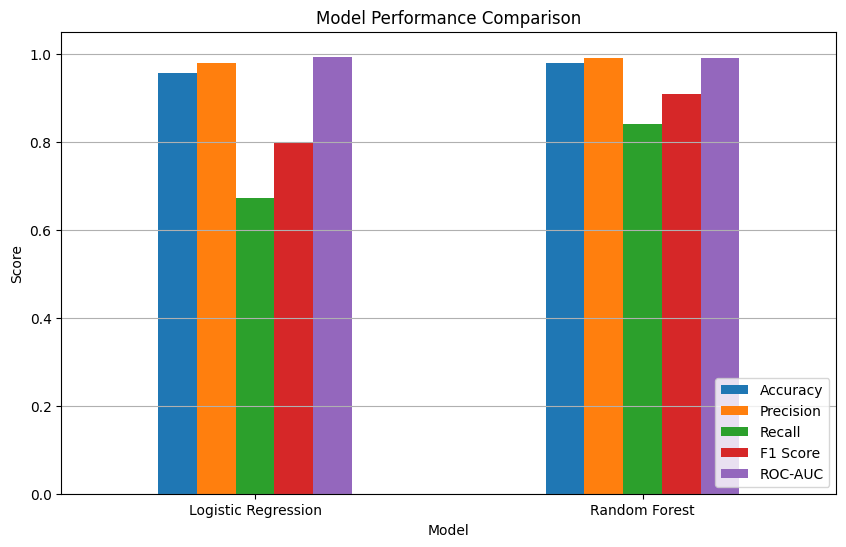

In [ ]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")
plt.show()

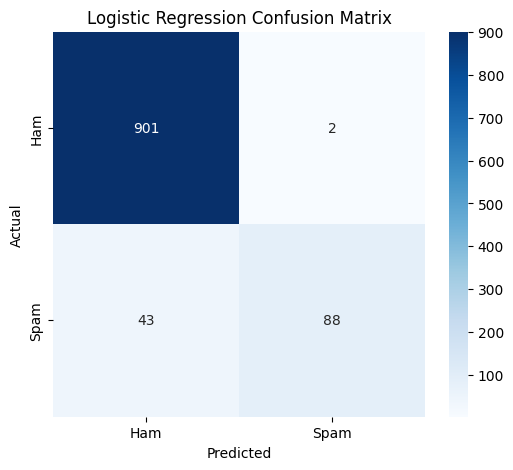

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

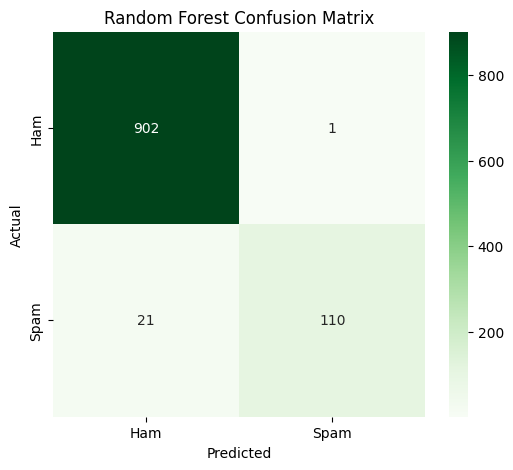

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

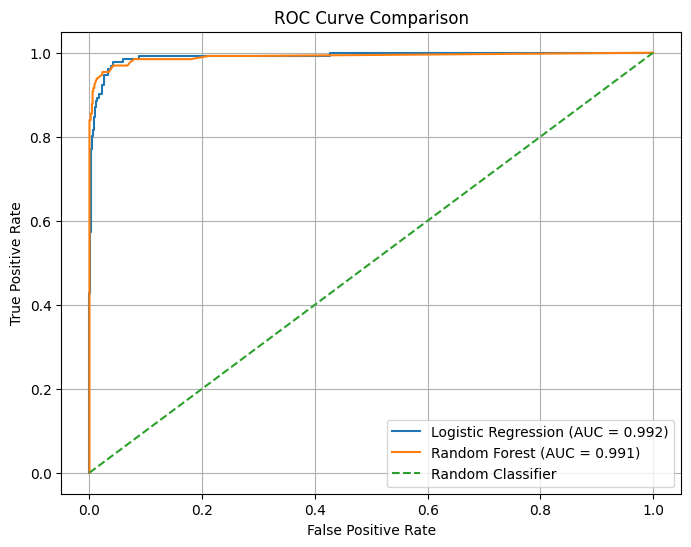

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_roc_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print("Logistic Regression Classification Report")
print("-------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Ham", "Spam"]
    )
)

Logistic Regression Classification Report
-------------------------------------------
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.98       903
        Spam       0.98      0.67      0.80       131

    accuracy                           0.96      1034
   macro avg       0.97      0.83      0.89      1034
weighted avg       0.96      0.96      0.95      1034



In [ ]:
print("Random Forest Classification Report")
print("-----------------------------------")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Ham", "Spam"]
    )
)

Random Forest Classification Report
-----------------------------------
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.99      0.84      0.91       131

    accuracy                           0.98      1034
   macro avg       0.98      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [ ]:
def predict_spam(message):
    message_tfidf = vectorizer.transform([message])

    prediction = random_forest_model.predict(message_tfidf)[0]
    probability = random_forest_model.predict_proba(message_tfidf)[0][1]

    if prediction == 1:
        result = "SPAM"
    else:
        result = "HAM"

    print("Message:", message)
    print("Prediction:", result)
    print("Spam Probability:", round(probability * 100, 2), "%")

In [ ]:
predict_spam(
    "Congratulations! You have won a free prize. Click now to claim."
)

Message: Congratulations! You have won a free prize. Click now to claim.
Prediction: SPAM
Spam Probability: 68.0 %
Message: Hi, are we meeting for class tomorrow?
Prediction: HAM
Spam Probability: 0.0 %
Model results saved successfully!
